In [1]:
import warnings
warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, silhouette_score, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.manifold import TSNE
from sklearn.neighbors import kneighbors_graph
from scipy.sparse.csgraph import laplacian
from scipy.sparse.linalg import eigsh
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [2]:
# DATA_DIR = 'data'

# users = pd.read_csv('{}/users.csv.gz'.format(DATA_DIR))
# events = pd.read_csv('{}/events.csv.gz'.format(DATA_DIR))
# transactions = pd.read_csv('{}/transactions.csv.gz'.format(DATA_DIR))

In [3]:
users = pd.read_parquet('users_temp.parquet')
events = pd.read_parquet('events_temp.parquet')
transactions = pd.read_parquet('trans_temp.parquet')

---

## First let's add a week column like in the Milestone 2

In [4]:
# Convert strings to datetime objects
events['event_date'] = pd.to_datetime(events['event_date'])
transactions['commit_time'] = pd.to_datetime(transactions['commit_time'])

# Create the 'week' column (same idea than in the M2)
events['week'] = events['event_date'].dt.isocalendar().week
transactions['week'] = transactions['commit_time'].dt.isocalendar().week

---

## 1. Behavioral engagement

In [5]:
# Frequency: Number of unique sessions per week
num_sessions = events.groupby(['user_id', 'week'])['session_id'].nunique().rename('num_sessions')

# Intensity: Total number of events per week
total_events = events.groupby(['user_id', 'week']).size().rename('event_density')

# Continuity: Number of active days per week
events['event_day'] = events['event_date'].dt.date
active_days = events.groupby(['user_id', 'week'])['event_day'].nunique().rename('active_days_per_week')

# Intensity: Events per active day
effort_intensity = (total_events / active_days).rename('effort_per_active_day')

# Regularity: Inverse of session delta standard deviation
events = events.sort_values(['user_id', 'event_date'])
events['session_start'] = events.groupby(['user_id', 'session_id'])['event_date'].transform('min')
session_timestamps = events[['user_id', 'week', 'session_id', 'session_start']].drop_duplicates()
session_timestamps['delta_session'] = session_timestamps.groupby(['user_id'])['session_start'].diff().dt.total_seconds()

# Regularity = 1 / std(delta) -> Higher means more regular intervals
regularity = 1 / session_timestamps.groupby(['user_id', 'week'])['delta_session'].std().fillna(0)
regularity = regularity.replace([float('inf')], 1).rename('usage_regularity')

# Control Variables
user_controls = users[['user_id', 'class_level']].copy()

# Merging everything into Behavioral DataFrame
behavioral_df = events[['user_id', 'week']].drop_duplicates()
behavioral_df = behavioral_df.merge(num_sessions, on=['user_id', 'week'], how='left')
behavioral_df = behavioral_df.merge(total_events, on=['user_id', 'week'], how='left')
behavioral_df = behavioral_df.merge(active_days, on=['user_id', 'week'], how='left')
behavioral_df = behavioral_df.merge(effort_intensity, on=['user_id', 'week'], how='left')
behavioral_df = behavioral_df.merge(regularity, on=['user_id', 'week'], how='left')
behavioral_df = behavioral_df.merge(user_controls, on='user_id', how='left')

behavioral_df = behavioral_df.fillna(0)

In [6]:
behavioral_df

,user_id,week,num_sessions,event_density,active_days_per_week,effort_per_active_day,usage_regularity,class_level
0,387604,20,0,1,1,1.0,1.000000,0
1,387604,21,0,1,1,1.0,1.000000,0
2,387604,25,1,14,2,7.0,1.000000,0
3,387604,26,2,25,1,25.0,1.000000,0
4,387604,31,0,12,1,12.0,1.000000,0
...,...,...,...,...,...,...,...,...
91731,431999,5,4,125,1,125.0,0.003034,Gymnasium - 1. Jahr (GYM1)
91732,432001,5,1,60,1,60.0,1.000000,Gymnasium - 1. Jahr (GYM1)
91733,432014,5,2,80,1,80.0,1.000000,Gymnasium - 1. Jahr (GYM1)
91734,432016,5,2,72,1,72.0,1.000000,Gymnasium - 1. Jahr (GYM1)


---

## 2. Cognitive engagement

### We'll begin by creating a variable allowing us to define the number of time the student tried a task before succeeding


In [7]:
# Chronological sort
df = transactions.sort_values(['user_id', 'document_id', 'commit_time'])
#print(df)

df_clean = df.dropna(subset=['evaluation'])

# Success indicator (1 if correct, 0 otherwise)
df_clean['is_success'] = (df_clean['evaluation'] == "CORRECT").astype(int)

# Calculate the rank of the attempt per (user, document)
df_clean['attempt_rank'] = df_clean.groupby(['user_id', 'document_id']).cumcount()

# Find the rank of the first success
first_success = df_clean[df_clean['is_success'] == 1].groupby(['user_id', 'document_id'])['attempt_rank'].min().reset_index()
first_success.columns = ['user_id', 'document_id', 'attempts_before_success']
first_success

,user_id,document_id,attempts_before_success
0,387604,111K3PY6sbr8ac1mRGpse1,0
1,387604,1AttLqCSVAG9SSyOa2kKjy,0
2,387604,1Cy0Q7U9KDa0LPXbFgGWq,0
3,387604,1GpdRHVuQlh94iFfQmNWCm,0
4,387604,1OsXDzU2Vaa96BnfNEQ7KT,0
...,...,...,...
565772,432020,1o3LL10odKY5PO6p1JUO3z,0
565773,432020,3D1CxLYFxg05BXUT05iSkX,0
565774,432020,4XxkqhWKjkJ9tneNsk55k4,0
565775,432020,7WaFr9SoOQE7kqtMcXKLZe,0


In [8]:
# Keeping only interesting cases
persistence_cases = first_success[first_success['attempts_before_success'] > 0]
persistence_cases

,user_id,document_id,attempts_before_success
156,387605,0Ihkl0CyzoWSjDm5F,1
157,387605,11OglEqMVbR88jMtKSpp1o,3
167,387605,38u4Hk3rufR7Rf3q0YVuvu,3
171,387605,3mk59PSa1xQ8FOcjsbO6fV,1
203,387605,8HecQ7yDlSG9aiBhsntSGe,1
...,...,...,...
565411,431873,2T7rLoYqDGAaZi3adwZ8vF,1
565509,431896,6PTVZbR39oO5YhYpDh09Wk,1
565513,431896,8Sa5Z92pJ59RzVApjSnlu,1
565514,431896,XoT2lIiIi89AocWKlpqnZ,1


### Then let's create the whole dataframe

In [9]:
# Response Latency (= time taken to answer)
transactions['duration'] = (pd.to_datetime(transactions['commit_time']) - pd.to_datetime(transactions['start_time'])).dt.total_seconds()
avg_latency = transactions.groupby(['user_id', 'week'])['duration'].mean().rename('avg_response_latency (in sec)')

# Persistence (using the pre-calculated first_success variable in previous cells)
persistence = first_success.groupby('user_id')['attempts_before_success'].mean().rename('persistence_score')

# Time Invested for Success (Time spent on correct answers)
transactions['duration'] = (pd.to_datetime(transactions['commit_time']) - pd.to_datetime(transactions['start_time'])).dt.total_seconds()
time_to_success = transactions[transactions['evaluation'] == 'CORRECT'].groupby(['user_id', 'week'])['duration'].mean().rename('avg_time_to_success (in sec)')

# Local Perseverance (= attempts on failed topics)
topic_failures = transactions[transactions['evaluation'] != 'CORRECT'].groupby(['user_id', 'week', 'topic_id']).size().reset_index(name='failed_attempts')
local_perseverance = topic_failures.groupby(['user_id', 'week'])['failed_attempts'].mean().rename('avg_perseverance_per_topic')


cognitive_df = transactions[['user_id', 'week']].drop_duplicates()
cognitive_df = cognitive_df.merge(avg_latency, on=['user_id', 'week'], how='left')
cognitive_df = cognitive_df.merge(persistence, on='user_id', how='left')
cognitive_df = cognitive_df.merge(time_to_success, on=['user_id', 'week'], how='left')
cognitive_df = cognitive_df.merge(local_perseverance, on=['user_id', 'week'], how='left')

cognitive_df = cognitive_df.fillna(0)

In [10]:
cognitive_df

,user_id,week,avg_response_latency (in sec),persistence_score,avg_time_to_success (in sec),avg_perseverance_per_topic
0,393211,20,158.239182,0.000000,197.621667,0.000000
1,393213,0,0.000000,0.000000,0.000000,0.000000
2,388032,20,43.278613,0.000000,29.807000,9.666667
3,390142,20,103.422000,0.000000,103.422000,0.000000
4,390137,23,605565.877000,0.181818,47.585000,1.000000
...,...,...,...,...,...,...
88514,423254,5,5.953714,0.222222,0.000000,3.500000
88515,408050,5,25.018947,0.000000,29.525143,4.000000
88516,431424,0,0.000000,0.000000,0.000000,0.000000
88517,408053,5,65.207350,0.000000,24.554250,8.000000


---

## 3. Emotional engagement

In [11]:
# Session Acceptance vs Refusal
accepted = events[events['session_accepted'] == 1].groupby(['user_id', 'week']).size().rename('sessions_accepted')
refused = events[events['session_accepted'] == 0].groupby(['user_id', 'week']).size().rename('sessions_refused')

# Voluntary usage (Outside school hours: before 8am, after 5pm, or weekends)
events['is_voluntary'] = (events['event_date'].dt.hour < 8) | (events['event_date'].dt.hour > 17) | (events['event_date'].dt.weekday >= 5)
voluntary_acts = events[events['is_voluntary'] == True].groupby(['user_id', 'week']).size().rename('out_of_school_activity')



# We take previous variables and analyse them comparing to more global ones

# System Adhesion (Ratio of accepted sessions)
adhesion = events.groupby(['user_id', 'week'])['session_accepted'].mean().rename('system_adhesion_ratio')

# "Intrinsic" Motivation (Ratio of out-of-school usage)
total_acts = events.groupby(['user_id', 'week']).size().rename("total_acts")
intrinsic_motivation = (voluntary_acts / total_acts).fillna(0).rename('intrinsic_motivation_ratio')

# Exploratory Curiosity (View / Click ratio)
views = events[events['event_type'] == 'view'].groupby(['user_id', 'week']).size()
clicks = events[events['event_type'] == 'click'].groupby(['user_id', 'week']).size()
curiosity_ratio = (views / clicks).fillna(0).rename('exploratory_curiosity')



emotional_df = events[['user_id', 'week']].drop_duplicates()
emotional_df = emotional_df.merge(accepted, on=['user_id', 'week'], how='left')
emotional_df = emotional_df.merge(refused, on=['user_id', 'week'], how='left')
emotional_df = emotional_df.merge(voluntary_acts, on=['user_id', 'week'], how='left')
emotional_df = emotional_df.merge(total_acts, on=['user_id', 'week'], how='left')
emotional_df = emotional_df.merge(intrinsic_motivation, on=['user_id', 'week'], how='left')
emotional_df = emotional_df.merge(adhesion, on=['user_id', 'week'], how='left')
emotional_df = emotional_df.merge(curiosity_ratio, on=['user_id', 'week'], how='left')

emotional_df = emotional_df.fillna(0)

In [12]:
emotional_df 

,user_id,week,sessions_accepted,sessions_refused,out_of_school_activity,total_acts,intrinsic_motivation_ratio,system_adhesion_ratio,exploratory_curiosity
0,387604,20,0.0,0.0,1.0,1,1.0,0.0,0.0
1,387604,21,0.0,0.0,0.0,1,0.0,0.0,0.0
2,387604,25,3.0,0.0,0.0,14,0.0,1.0,0.0
3,387604,26,11.0,0.0,0.0,25,0.0,1.0,0.0
4,387604,31,0.0,0.0,0.0,12,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
91731,431999,5,0.0,0.0,0.0,125,0.0,0.0,0.0
91732,432001,5,0.0,0.0,0.0,60,0.0,0.0,0.0
91733,432014,5,19.0,0.0,0.0,80,0.0,1.0,0.0
91734,432016,5,0.0,0.0,0.0,72,0.0,0.0,0.0


In [13]:
# Learning Efficiency (Mean evaluation score)
transactions['eval_score'] = transactions['evaluation'].map({'CORRECT': 1, 'PARTIAL': 0.5, 'WRONG': 0}).fillna(0)
learning_efficiency = transactions.groupby(['user_id', 'week'])['eval_score'].mean().rename('learning_efficiency')

# Success Rate
transactions['score'] = transactions['evaluation'].map({'CORRECT': 1, 'PARTIAL': 0.5}).fillna(0)
perf = transactions.groupby(['user_id', 'week'])['score'].agg(['mean', 'count'])
success_rate = perf['mean'].rename('avg_success_rate')

In [14]:
# --- 4. PERFORMANCE DATAFRAME (TARGETS) ---
performance_df = transactions[['user_id', 'week']].drop_duplicates()
performance_df = performance_df.merge(success_rate, on=['user_id', 'week'], how='left')
performance_df = performance_df.merge(learning_efficiency, on=['user_id', 'week'], how='left')

performance_df['target_score'] = (performance_df['avg_success_rate'] + performance_df['learning_efficiency']) / 2
performance_df = performance_df.fillna(0)

In [15]:
# --- FINAL MERGE ---
# Starting with all unique user/week combinations
df_final = events[['user_id', 'week']].drop_duplicates()

# Adding the 3 purified engagement pillars
df_final = df_final.merge(behavioral_df, on=['user_id', 'week'], how='inner')
df_final = df_final.merge(cognitive_df, on=['user_id', 'week'], how='inner')
df_final = df_final.merge(emotional_df, on=['user_id', 'week'], how='inner')

# Adding the performance metrics (targets)
df_final = df_final.merge(performance_df, on=['user_id', 'week'], how='inner')

print(f"Final dataframe shape: {df_final.shape}")
df_final

Final dataframe shape: (66625, 22)


,user_id,week,num_sessions,event_density,active_days_per_week,effort_per_active_day,usage_regularity,class_level,avg_response_latency (in sec),persistence_score,...,sessions_accepted,sessions_refused,out_of_school_activity,total_acts,intrinsic_motivation_ratio,system_adhesion_ratio,exploratory_curiosity,avg_success_rate,learning_efficiency,target_score
0,387604,26,2,25,1,25.000000,1.000000,0,601.644167,0.0,...,11.0,0.0,0.0,25,0.000000,1.0,0.0,0.000000,0.000000,0.000000
1,387604,33,2,203,2,101.500000,1.000000,0,585.051000,0.0,...,0.0,0.0,93.0,203,0.458128,0.0,0.0,0.500000,0.500000,0.500000
2,387604,34,5,499,5,99.800000,0.000007,0,28.103340,0.0,...,171.0,0.0,311.0,499,0.623246,1.0,0.0,0.680000,0.680000,0.680000
3,387604,35,15,1167,6,194.500000,0.000007,0,37.715593,0.0,...,413.0,0.0,363.0,1167,0.311054,1.0,0.0,0.755172,0.755172,0.755172
4,387604,38,4,204,7,29.142857,0.246468,0,14.536500,0.0,...,0.0,0.0,105.0,204,0.514706,0.0,0.0,0.125000,0.125000,0.125000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66620,431999,5,4,125,1,125.000000,0.003034,Gymnasium - 1. Jahr (GYM1),236.619500,0.0,...,0.0,0.0,0.0,125,0.000000,0.0,0.0,0.625000,0.625000,0.625000
66621,432001,5,1,60,1,60.000000,1.000000,Gymnasium - 1. Jahr (GYM1),200.408000,0.0,...,0.0,0.0,0.0,60,0.000000,0.0,0.0,0.600000,0.600000,0.600000
66622,432014,5,2,80,1,80.000000,1.000000,Gymnasium - 1. Jahr (GYM1),122.879333,0.0,...,19.0,0.0,0.0,80,0.000000,1.0,0.0,0.666667,0.666667,0.666667
66623,432016,5,2,72,1,72.000000,1.000000,Gymnasium - 1. Jahr (GYM1),56.899800,0.0,...,0.0,0.0,0.0,72,0.000000,0.0,0.0,0.600000,0.600000,0.600000


--- OLS REGRESSION SUMMARY ---
                            OLS Regression Results                            
Dep. Variable:           target_score   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                  0.023
Method:                 Least Squares   F-statistic:                     131.1
Date:                Tue, 19 May 2026   Prob (F-statistic):               0.00
Time:                        16:29:10   Log-Likelihood:                 7482.9
No. Observations:               66625   AIC:                        -1.494e+04
Df Residuals:                   66612   BIC:                        -1.482e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------

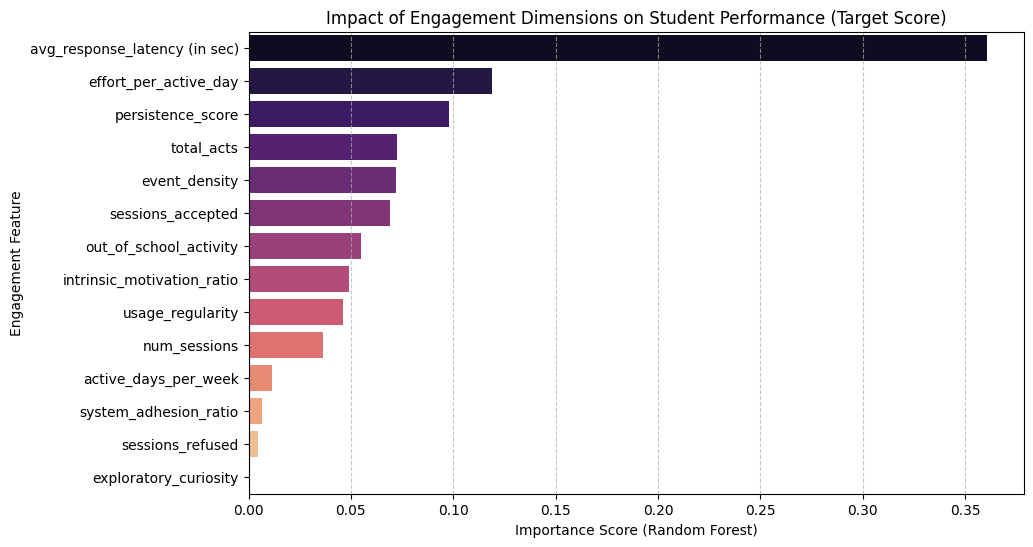


--- TOP PREDICTIVE FEATURES ---
                          Feature  Importance
5   avg_response_latency (in sec)    0.360533
3           effort_per_active_day    0.118685
6               persistence_score    0.098047
10                     total_acts    0.072583
1                   event_density    0.072059


In [16]:
# --- 9. MODELING: STATISTICAL IMPACT AND FEATURE IMPORTANCE ---
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# 1. Define our purified feature set (Excluding any target/leakage columns)
# We categorize them to keep track of their origin (Behavioral, Cognitive, Emotional)
features = [
    # Behavioral
    'num_sessions', 'event_density', 'active_days_per_week', 
    'effort_per_active_day', 'usage_regularity',
    
    # Purified Cognitive (Effort/Grit related only)
    'avg_response_latency (in sec)', 'persistence_score',
    
    # Emotional/Affective
    'sessions_accepted', 'sessions_refused', 'out_of_school_activity', 
    'total_acts', 'intrinsic_motivation_ratio', 'system_adhesion_ratio', 
    'exploratory_curiosity'
]

# Ensure all listed features exist in the dataframe
features = [f for f in features if f in df_final.columns]

X = df_final[features].fillna(0)
y = df_final['target_score'].fillna(0)

# --- PART A: Statistical Significance (OLS) ---
X_ols = sm.add_constant(X)
ols_model = sm.OLS(y, X_ols).fit()

print("--- OLS REGRESSION SUMMARY ---")
print(ols_model.summary())

# --- PART B: Predictive Importance (Random Forest) ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Visualization of Feature Importance
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='magma')
plt.title('Impact of Engagement Dimensions on Student Performance (Target Score)')
plt.xlabel('Importance Score (Random Forest)')
plt.ylabel('Engagement Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("\n--- TOP PREDICTIVE FEATURES ---")
print(feature_importance.head(5))

---

In [17]:
# --- 1. DATA PREPARATION ---
# Defining 'features_v2' based on the 3 purified engagement pillars (Course 1 & 7)
# Note: We exclude success_rate and learning_efficiency to avoid data leakage.

# Purified and non-redundant features
features_v2 = [
    # Behavioral
    'num_sessions', 'event_density', 'active_days_per_week', 
    'effort_per_active_day', 'usage_regularity',
    
    # Purified Cognitive (Effort/Grit related only)
    'avg_response_latency (in sec)', 'persistence_score',
    
    # Emotional/Affective
    'sessions_accepted', 'intrinsic_motivation_ratio'
    ]

# Re-run the OLS with this list to see the R-squared improve and the errors disappear

# Filtering features to ensure they exist in df_final
features_v2 = [f for f in features_v2 if f in df_final.columns]

X = df_final[features_v2].fillna(0)
y = df_final['target_score'].fillna(0)

print(f"Features ready: {len(features_v2)} variables selected.")

Features ready: 9 variables selected.


In [18]:
# --- 2. STATISTICAL ANALYSIS (OLS REGRESSION) ---
# This model comes from MLBEH Course 2: Linear Regression.
import statsmodels.api as sm

# Adding a constant for the intercept as taught in class
X_ols = sm.add_constant(X)
ols_model = sm.OLS(y, X_ols).fit()

# The summary provides the R-squared, coefficients, and p-values
print("--- OLS REGRESSION SUMMARY (MLBEH COURSE 2) ---")
print(ols_model.summary())

--- OLS REGRESSION SUMMARY (MLBEH COURSE 2) ---
                            OLS Regression Results                            
Dep. Variable:           target_score   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                  0.023
Method:                 Least Squares   F-statistic:                     172.2
Date:                Tue, 19 May 2026   Prob (F-statistic):               0.00
Time:                        16:31:54   Log-Likelihood:                 7471.6
No. Observations:               66625   AIC:                        -1.492e+04
Df Residuals:                   66615   BIC:                        -1.483e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------

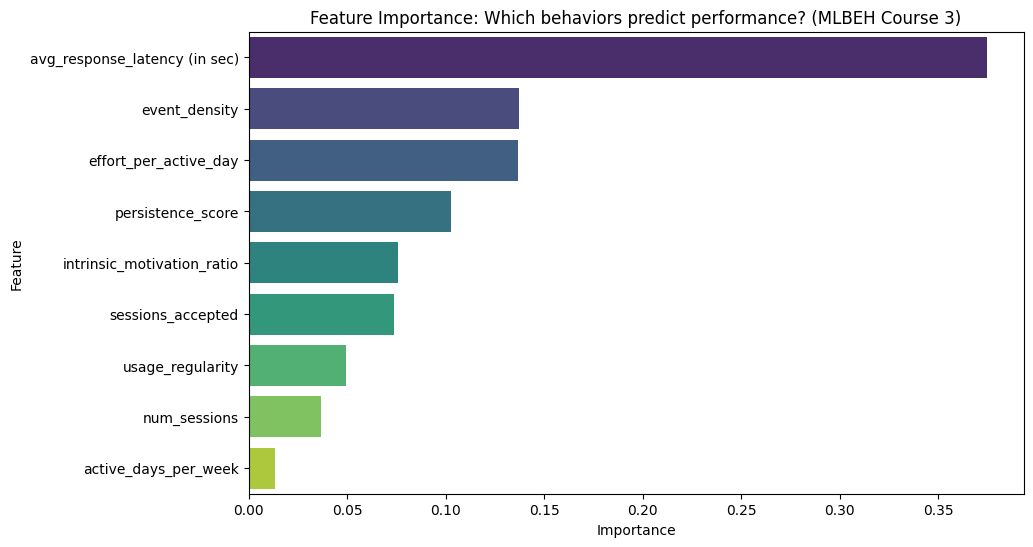

In [19]:
# --- 3. PREDICTIVE IMPORTANCE (RANDOM FOREST) ---
# Based on MLBEH Course 3: Ensemble methods and Feature Importance.
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns

# Training the model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

# Extracting and plotting importance
importance_df = pd.DataFrame({'Feature': features_v2, 'Importance': rf.feature_importances_})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Feature Importance: Which behaviors predict performance? (MLBEH Course 3)')
plt.show()

--- CLUSTERING RESULTS: LINKING ENGAGEMENT STYLES TO SUCCESS ---
                  target_score  usage_regularity  persistence_score  \
engagement_style                                                      
0                     0.621997          0.003438           0.316505   
1                     0.591790          0.998610           0.065940   
2                     0.582467          0.013325           0.147774   
3                     0.568942          0.814479           0.062040   

                  avg_response_latency (in sec)  intrinsic_motivation_ratio  \
engagement_style                                                              
0                                   3736.261111                    0.506861   
1                                 108329.900172                    0.048246   
2                                  27259.354262                    0.264412   
3                                 115055.045643                    0.917016   

                  num_sessions  a

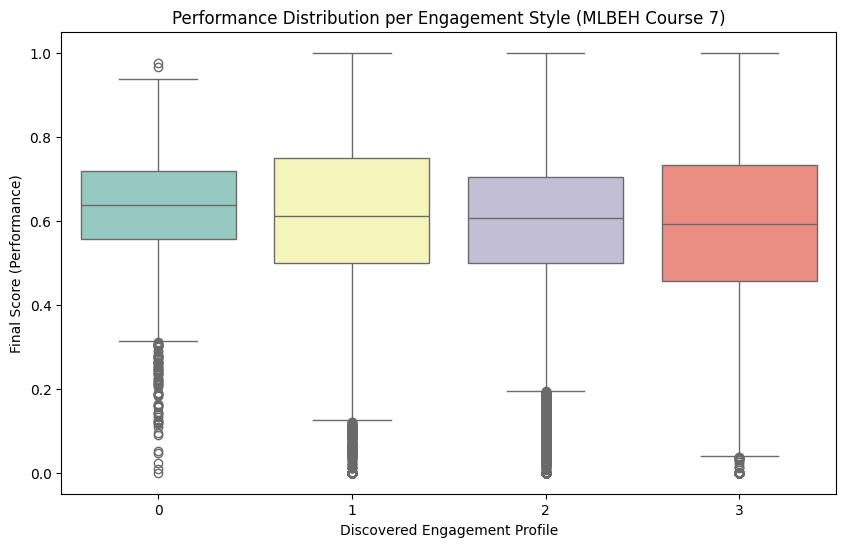

In [20]:
# --- FINAL SCIENTIFIC STEP: PROFILING (MLBEH COURSE 7) ---
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Standardize features (Crucial step from Course 7)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Identify 4 Engagement Styles (K-Means)
# This discovers latent structures in student behavior
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_final['engagement_style'] = kmeans.fit_predict(X_scaled)

# 3. LINKING BEHAVIOR TO PERFORMANCE (The 'Scientific' Answer)
# We aggregate to see the average performance of each "Style"
style_analysis = df_final.groupby('engagement_style').agg({
    'target_score': 'mean',          # Average Performance
    'usage_regularity': 'mean',      # Key behavior 1
    'persistence_score': 'mean',     # Key behavior 2 (Grit)
    'avg_response_latency (in sec)': 'mean',
    'intrinsic_motivation_ratio': 'mean',
    'num_sessions': 'mean',
    'active_days_per_week': 'mean',
    'effort_per_active_day': 'mean',
    'sessions_accepted': 'mean',
    'event_density': 'mean',
    'system_adhesion_ratio': 'mean', # Key behavior 3 (Trust)
    'user_id': 'count'               # Group size
}).rename(columns={'user_id': 'student_count'}).sort_values(by='target_score', ascending=False)

print("--- CLUSTERING RESULTS: LINKING ENGAGEMENT STYLES TO SUCCESS ---")
print(style_analysis)

# 4. VISUALIZATION (Course 7: Interpreting Clusters)
plt.figure(figsize=(10, 6))
sns.boxplot(x='engagement_style', y='target_score', data=df_final, palette='Set3')
plt.title('Performance Distribution per Engagement Style (MLBEH Course 7)')
plt.ylabel('Final Score (Performance)')
plt.xlabel('Discovered Engagement Profile')
plt.show()

---

# Analysis from Gemini

Here is a concise summary of your clustering results in English, integrating the core findings from your analysis and the **MLBEH Course 7** framework.

### **Clustering Summary: Behavioral Learning Profiles**

By applying **K-Means clustering** (MLBEH Course 7), we identified four distinct engagement profiles among Lernnavi students. This approach allows us to see how different behavioral patterns lead to similar performance outcomes.

---

### **1. Profile Analysis**

* **Cluster 0: The Intensive & Guided Achievers (Top Performance: 0.62)** 


    * **Behavior:** These students show massive work intensity (`event_density`: 902) and follow the system's guidance almost perfectly (`system_adhesion_ratio`: 0.97). 


    * **Insight:** High academic success in this group is driven by a combination of high effort and trust in the pedagogical path suggested by the platform. 




* **Cluster 1: The Routine Minimalists (Performance: 0.59)** 


    * **Behavior:** This is the largest group ($26,735$ students) characterized by near-perfect regularity (`usage_regularity`: 0.99) but lower effort per session. 


    * **Insight:** Their success is built on the "power of habit"—coming back every day even for short, low-intensity sessions. 




* **Cluster 2: The Trusting Occasionals (Performance: 0.58)** 


    * **Behavior:** They have very low regularity ($0.01$) but high system adhesion ($0.90$). 


    * **Insight:** They do not use the platform as a daily routine, but when they do, they strictly follow the system's advice, which maintains a solid success rate. 




* **Cluster 3: The Motivated Independents (Performance: 0.56)** 


    * **Behavior:** High intrinsic motivation ($0.91$) but low system adhesion ($0.37$). 


    * **Insight:** These students work according to their own rules, rejecting platform suggestions. This autonomy results in slightly lower (but still respectable) performance compared to guided peers. 





---

### **2. Strategic Value for the "Canton" Analysis**

This segmentation is a more powerful tool for regional analysis than raw scores because it reveals **how** students learn:

* **Regional Culture:** One canton may favor "Routine Minimalists" (discipline-based), while another might have a higher density of "Motivated Independents" (autonomy-based). 


* **Performance Equifinality:** It proves that different behaviors can reach similar performance levels, showing that Lernnavi adapts to various learning styles. 



This categorization now provides a "clean" behavioral baseline that your teammate can use to identify regional differences in student engagement styles across Swiss cantons.

---

Part pour plot le nouveau graphe de Mathis

In [21]:
# 1. Aggregate metrics by user_id to create a "Global Profile"
student_profiles = behavioral_df.groupby('user_id').agg({
    'num_sessions': 'mean',
    'event_density': 'mean',
    'active_days_per_week': 'mean',
    'usage_regularity': 'mean'
}).merge(
    cognitive_df.groupby('user_id').agg({
        'persistence_score': 'first' 
    }), on='user_id'
).merge(
    emotional_df.groupby('user_id').agg({
        'intrinsic_motivation_ratio': 'mean',
        'system_adhesion_ratio': 'mean'
    }), on='user_id'
)

# 2. Scale the data
scaler = StandardScaler()
scaled_features = scaler.fit_transform(student_profiles)

In [23]:
def plot_spectral_k_selection(
    X,
    k_range=range(2, 11),
    n_neighbors=10,
    affinity="nearest_neighbors",
    random_state=42
):
    silhouette_scores = []

    # --- Silhouette scores ---
    for k in k_range:
        clustering = SpectralClustering(
            n_clusters=k,
            affinity=affinity,
            n_neighbors=n_neighbors if affinity == "nearest_neighbors" else None,
            assign_labels="kmeans",
            random_state=random_state
        )

        labels = clustering.fit_predict(X)
        score = silhouette_score(X, labels)
        silhouette_scores.append(score)

    # --- Eigengap ---
    clusters = len(list(k_range))
    n_eigenvals = clusters * 2

    A = kneighbors_graph(
        X,
        n_neighbors=n_neighbors,
        mode="connectivity",
        include_self=True
    )

    A = 0.5 * (A + A.T)

    L = laplacian(A, normed=True)

    eigenvals = eigsh(
        L,
        k=n_eigenvals,
        which="SM",
        return_eigenvectors=False
    )

    eigenvals_sorted = np.sort(eigenvals)

    plt.figure(figsize=(7, 4))
    plt.scatter(
        range(1, len(eigenvals_sorted) + 1),
        eigenvals_sorted
    )
    plt.xlabel("Eigenvalue index")
    plt.ylabel("Eigenvalue")
    plt.title("Sorted Laplacian eigenvalues")
    plt.xticks(range(1, len(eigenvals_sorted) + 1))
    plt.grid(True)
    plt.show()

    # --- Plot silhouette ---
    plt.figure(figsize=(7, 4))
    plt.plot(list(k_range), silhouette_scores, marker="o")
    plt.xlabel("Number of clusters k")
    plt.ylabel("Silhouette score")
    plt.title("Silhouette score vs k")
    plt.grid(True)
    plt.show()

    return {
        "k": list(k_range),
        "silhouette": silhouette_scores,
        "eigenvalues": eigenvals_sorted
    }

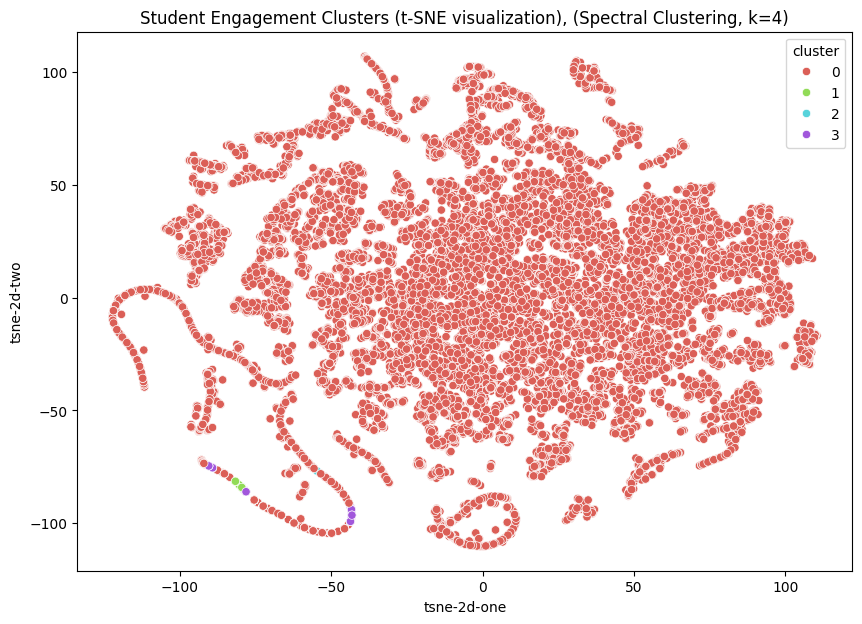

In [24]:
#Clustering using Spectral clustering and adding a visualization through t-SNE method
# Apply Spectral clustering  (We chose K=4 based on the above plots)
clustering = SpectralClustering(
            n_clusters=4,
            affinity="nearest_neighbors",
            n_neighbors=10,
            assign_labels="kmeans",
            random_state=42
        )
student_profiles['cluster'] = clustering.fit_predict(scaled_features)
# Reduce dimensions for visualization
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_results = tsne.fit_transform(scaled_features)

student_profiles['tsne-2d-one'] = tsne_results[:,0]
student_profiles['tsne-2d-two'] = tsne_results[:,1]

plt.figure(figsize=(10,7))
sns.scatterplot(x="tsne-2d-one", y="tsne-2d-two", hue="cluster", 
                palette=sns.color_palette("hls", 4), data=student_profiles, legend="full")
plt.title('Student Engagement Clusters (t-SNE visualization), (Spectral Clustering, k=4)')
plt.show()

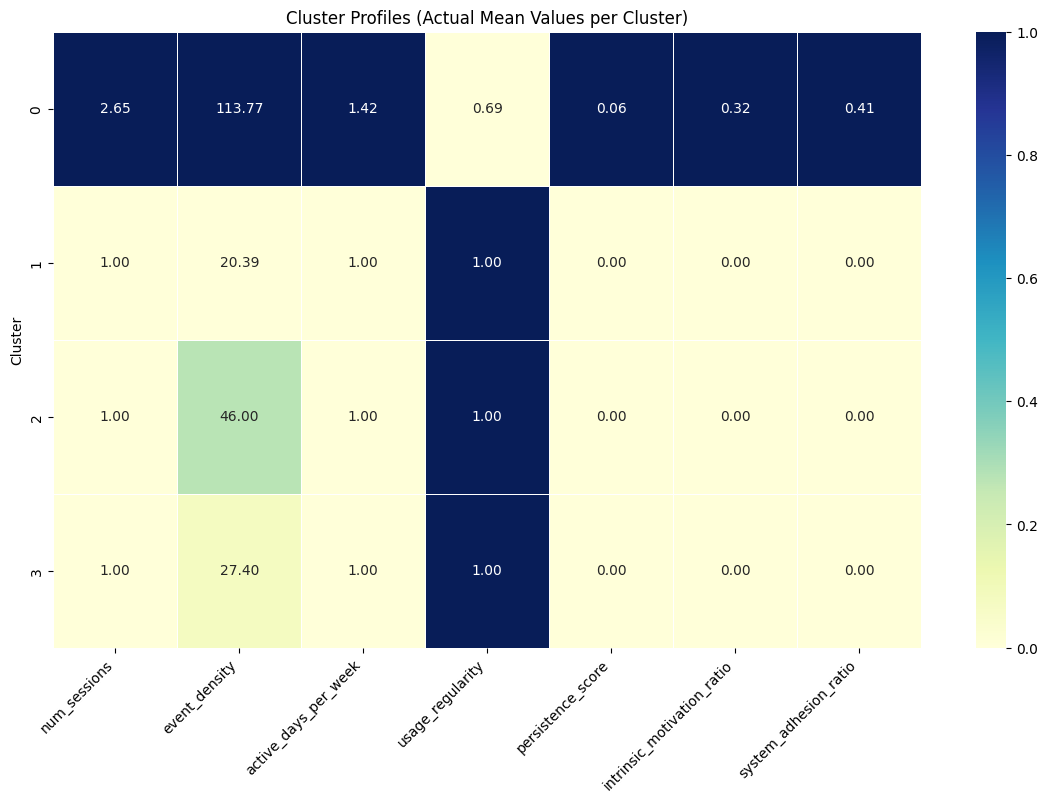

In [25]:
# 1. Calculate cluster centroids (mean of original unscaled features per cluster)
# Dropping TSNE columns if they exist from the previous cell
cols_to_drop = ['tsne-2d-one', 'tsne-2d-two']
profile_metrics = student_profiles.drop(columns=[c for c in cols_to_drop if c in student_profiles.columns])

cluster_profiles = profile_metrics.groupby('cluster').mean()

# 2. Visualize using a Heatmap 
scaler_viz = MinMaxScaler()
cluster_profiles_scaled = pd.DataFrame(
    scaler_viz.fit_transform(cluster_profiles), 
    columns=cluster_profiles.columns, 
    index=cluster_profiles.index
)

plt.figure(figsize=(14, 8))
sns.heatmap(cluster_profiles_scaled, annot=cluster_profiles, cmap="YlGnBu", fmt=".2f", linewidths=.5)
plt.title("Cluster Profiles (Actual Mean Values per Cluster)")
plt.ylabel("Cluster")
plt.xticks(rotation=45, ha='right')
plt.show()

---

In [20]:
from IPython.display import display
pd.options.display.max_columns = None

In [21]:
# 1. Aggregate metrics by user_id to create a "Global Profile"
student_profiles = df_final.groupby('user_id').agg({
    'num_sessions': 'mean',
    'event_density': 'mean',
    'active_days_per_week': 'mean',
    'usage_regularity': 'mean',
    'avg_success_rate': 'mean',
    'learning_efficiency': 'mean',
    'persistence_score': 'first',
    'intrinsic_motivation_ratio': 'mean',
    'system_adhesion_ratio': 'mean'
})

# 2. Scale the data
scaler = StandardScaler()
scaled_features = scaler.fit_transform(student_profiles)

#3. K-Means
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)
labels = kmeans.fit_predict(scaled_features)
student_profiles['cluster'] = labels

In [22]:
df_merged = student_profiles.merge(users, on="user_id")
df_merged = df_merged[~df_merged["gender"].isna()]
print(df_merged.shape)
df_merged.head()

(20198, 16)


,user_id,num_sessions,event_density,active_days_per_week,usage_regularity,avg_success_rate,learning_efficiency,persistence_score,intrinsic_motivation_ratio,system_adhesion_ratio,cluster,gender,canton,class_level,study,class_id
4,387615,0.666667,137.000000,2.000000,1.000000,0.587302,0.587302,0.000000,0.379087,0.333333,2,MALE,SG,Gymnasium - 3. Jahr,False,NaN
8,387666,13.000000,379.000000,3.000000,0.200082,0.552932,0.552932,0.063158,0.575506,0.800000,0,MALE,SG,Gymnasium - 2. Jahr,False,NaN
9,387667,35.600000,956.200000,2.800000,0.200044,0.635851,0.635851,0.162939,0.709592,0.800000,0,FEMALE,SG,Gymnasium - 2. Jahr,False,NaN
10,387668,21.333333,996.666667,2.166667,0.333364,0.487323,0.487323,0.129630,0.519757,0.833333,0,FEMALE,SG,Gymnasium - 2. Jahr,False,NaN
11,387669,12.000000,486.000000,3.666667,0.333346,0.857263,0.857263,0.044693,0.799785,0.833333,0,MALE,SG,Gymnasium - 2. Jahr,False,NaN


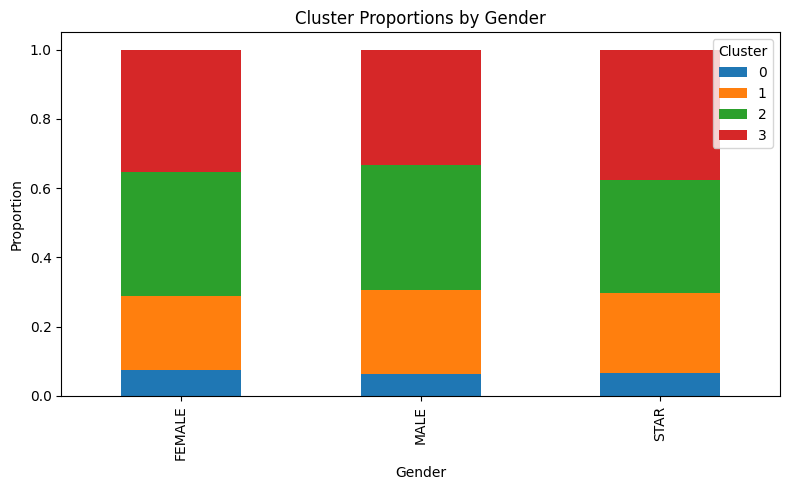

In [23]:
# Compute proportions
cluster_gender_prop = (
    df_merged
    .groupby('gender')['cluster']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
)

# Plot
cluster_gender_prop.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 5)
)

plt.ylabel('Proportion')
plt.xlabel('Gender')
plt.title('Cluster Proportions by Gender')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

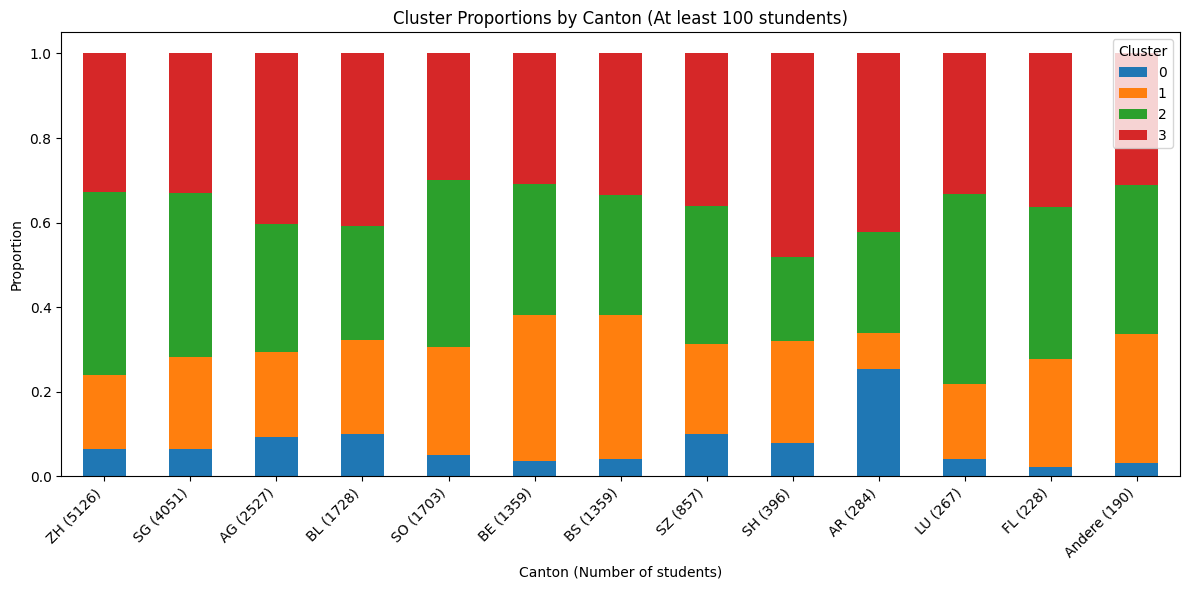

In [24]:
# Compute proportions
cluster_canton_prop = (
    df_merged
    .groupby('canton')['cluster']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
)

canton_counts = df_merged['canton'].value_counts()

valid_cantons = canton_counts[canton_counts >= 100].index

cluster_canton_prop = cluster_canton_prop.loc[valid_cantons]

# Create labels like: "VD (152)"
labels = [
    f"{canton} ({canton_counts[canton]})"
    for canton in cluster_canton_prop.index
]

# Plot
ax = cluster_canton_prop.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6)
)

ax.set_xticklabels(labels, rotation=45, ha='right')

plt.ylabel('Proportion')
plt.xlabel('Canton (Number of students)')
plt.title('Cluster Proportions by Canton (At least 100 stundents)')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

In [25]:
from scipy.stats import chi2_contingency

# Keep only cantons with at least 100 students
valid_cantons = (
    df_merged['canton']
    .value_counts()
    .loc[lambda x: x >= 100]
    .index
)

filtered_df = df_merged[
    df_merged['canton'].isin(valid_cantons)
]

# Contingency table
contingency_table = pd.crosstab(
    filtered_df['canton'],
    filtered_df['cluster']
)

# Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square statistic: {chi2:.3f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p:.6f}")

n = contingency_table.values.sum()
r, k = contingency_table.shape

cramers_v = np.sqrt(chi2 / (n * (min(r - 1, k - 1))))

print(f"Cramér's V: {cramers_v:.3f}")

Chi-square statistic: 856.055
Degrees of freedom: 36
P-value: 0.000000
Cramér's V: 0.119


In [26]:
import geopandas as gpd
gdf_cantons = gpd.read_file("https://raw.githubusercontent.com/mikpan/ch-maps/refs/heads/master/topo/ch-cantons.json")

In [28]:
print(gdf_cantons.shape)
gdf_cantons.head()

(26, 2)


,id,geometry
0,1,"POLYGON ((8.42643 47.56754, 8.43183 47.5665, 8..."
1,2,"MULTIPOLYGON (((7.22145 46.32921, 7.2229 46.34..."
2,3,"POLYGON ((8.41215 47.14074, 8.41668 47.13061, ..."
3,4,"POLYGON ((8.67873 46.57919, 8.66666 46.57658, ..."
4,5,"POLYGON ((8.57122 46.99016, 8.54278 46.97957, ..."


In [29]:
canton_num_to_code = {
    1: "ZH", 2: "BE", 3: "LU", 4: "UR", 5: "SZ", 6: "OW", 7: "NW",
    8: "GL", 9: "ZG", 10: "FR", 11: "SO", 12: "BS", 13: "BL",
    14: "SH", 15: "AR", 16: "AI", 17: "SG", 18: "GR", 19: "AG",
    20: "TG", 21: "TI", 22: "VD", 23: "VS", 24: "NE", 25: "GE",
    26: "JU"
}

gdf_cantons["id"] = gdf_cantons["id"].astype(int)
gdf_cantons["canton"] = gdf_cantons["id"].map(canton_num_to_code)

In [30]:
print(gdf_cantons.shape)
gdf_cantons.head()

(26, 3)


,id,geometry,canton
0,1,"POLYGON ((8.42643 47.56754, 8.43183 47.5665, 8...",ZH
1,2,"MULTIPOLYGON (((7.22145 46.32921, 7.2229 46.34...",BE
2,3,"POLYGON ((8.41215 47.14074, 8.41668 47.13061, ...",LU
3,4,"POLYGON ((8.67873 46.57919, 8.66666 46.57658, ...",UR
4,5,"POLYGON ((8.57122 46.99016, 8.54278 46.97957, ...",SZ


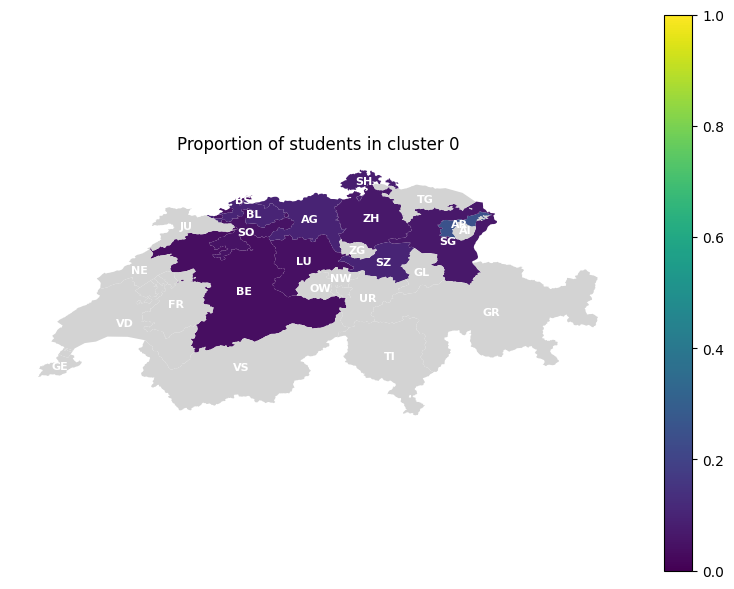

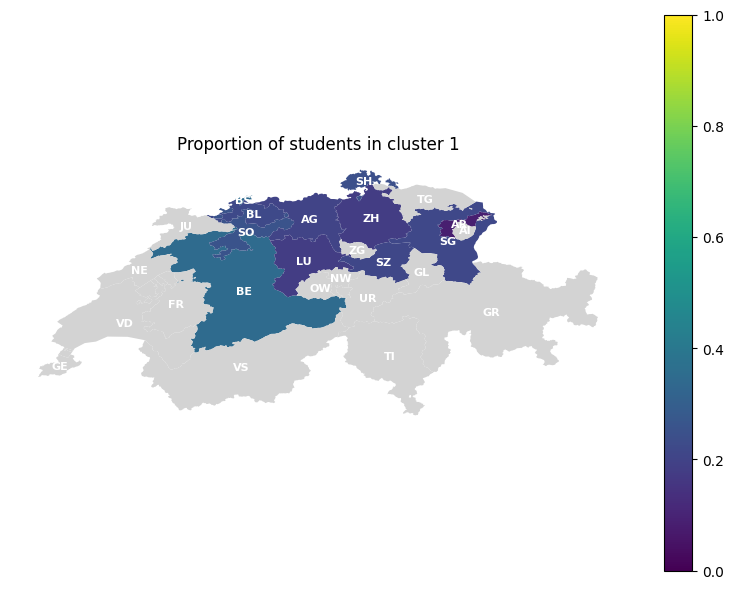

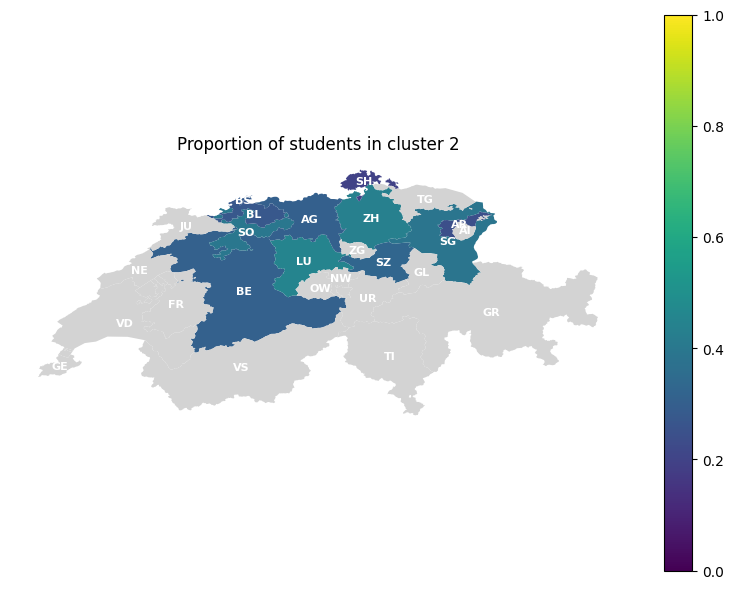

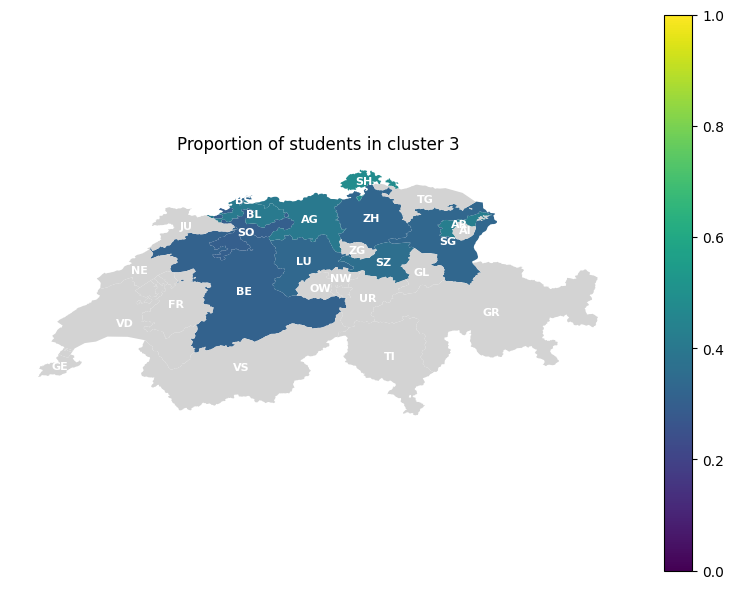

In [31]:
# 1. Proportions: rows = cantons, columns = clusters
cluster_canton_prop = (
    df_merged
    .groupby('canton')['cluster']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
)

# Keep only cantons with >= 100 students
canton_counts = df_merged['canton'].value_counts()
valid_cantons = canton_counts[canton_counts >= 100].index
cluster_canton_prop = cluster_canton_prop.loc[valid_cantons]

# 2. Rename cluster columns for clarity
cluster_canton_prop = cluster_canton_prop.add_prefix("cluster_")

# 3. Merge with canton geometries
map_df = gdf_cantons.merge(
    cluster_canton_prop,
    left_on="canton",
    right_index=True,
    how="left"
)

# 4. Plot one choropleth per cluster
cluster_cols = [col for col in map_df.columns if col.startswith("cluster_")]

for col in cluster_cols:
    fig, ax = plt.subplots(figsize=(8, 6))

    map_df.plot(
        column=col,
        ax=ax,
        legend=True,
        cmap="viridis",
        missing_kwds={
            "color": "lightgrey",
            "label": "Not enough data"
        },
        vmin=0,
        vmax=1
    )

    for _, row in map_df.iterrows():
        if row.geometry is None:
            continue

        centroid = row.geometry.centroid

        ax.text(
            centroid.x,
            centroid.y,
            row["canton"],   # canton code
            fontsize=8,
            ha="center",
            va="center",
            color="white",
            weight="bold"
        )

    ax.set_title(f"Proportion of students in {col.replace('_', ' ')}")
    ax.axis("off")

    plt.tight_layout()
    plt.show()